<a href="https://colab.research.google.com/github/meghna120105/AI-Revenue-Recovery-Agent/blob/main/Assignment_01_GAN_Transformer_LLM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# ============================================
# ASSIGNMENT 01
# GANs, Transformers and LLMs
# ============================================

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

PyTorch version: 2.11.0+cu128
GPU available: True
Using device: cuda


In [5]:
# ============================================
# STEP 3: LOAD MNIST DATASET
# ============================================

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=128,
    shuffle=True
)

print("Number of training images:", len(dataset))

100%|██████████| 9.91M/9.91M [00:00<00:00, 13.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 339kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.18MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.49MB/s]

Number of training images: 60000


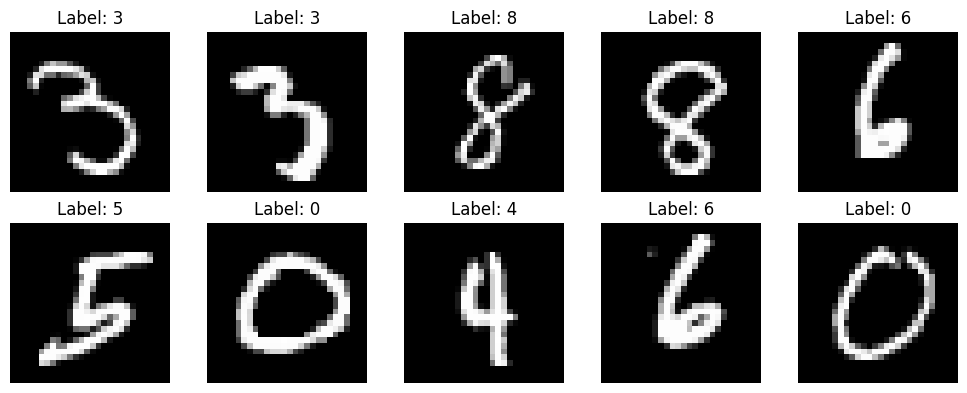

In [6]:
# Display sample MNIST images

images, labels = next(iter(dataloader))

plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.title(f"Label: {labels[i].item()}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [7]:

#  DCGAN GENERATOR


class Generator(nn.Module):

    def __init__(self, latent_dim=100):
        super(Generator, self).__init__()

        self.model = nn.Sequential(

            # 100 -> 128 x 7 x 7
            nn.ConvTranspose2d(
                latent_dim, 128,
                kernel_size=7,
                stride=1,
                padding=0,
                bias=False
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            # 7 x 7 -> 14 x 14
            nn.ConvTranspose2d(
                128, 64,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            # 14 x 14 -> 28 x 28
            nn.ConvTranspose2d(
                64, 1,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.Tanh()
        )

    def forward(self, z):
        return self.model(z)


latent_dim = 100

generator = Generator(latent_dim).to(device)

print(generator)

Generator(
  (model): Sequential(
    (0): ConvTranspose2d(100, 128, kernel_size=(7, 7), stride=(1, 1), bias=False)
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(64, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): Tanh()
  )
)


In [8]:

#  DCGAN DISCRIMINATOR


class Discriminator(nn.Module):

    def __init__(self):
        super(Discriminator, self).__init__()

        self.model = nn.Sequential(

            # 28 x 28 -> 14 x 14
            nn.Conv2d(
                1, 64,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.LeakyReLU(0.2, inplace=True),

            # 14 x 14 -> 7 x 7
            nn.Conv2d(
                64, 128,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            # 7 x 7 -> 1
            nn.Conv2d(
                128, 1,
                kernel_size=7,
                stride=1,
                padding=0,
                bias=False
            )
        )

    def forward(self, x):
        return self.model(x).view(-1)


discriminator = Discriminator().to(device)

print(discriminator)

Discriminator(
  (model): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 1, kernel_size=(7, 7), stride=(1, 1), bias=False)
  )
)


In [9]:

#  TRAIN DCGAN


criterion = nn.BCEWithLogitsLoss()

lr = 0.0002
beta1 = 0.5

optimizer_G = optim.Adam(
    generator.parameters(),
    lr=lr,
    betas=(beta1, 0.999)
)

optimizer_D = optim.Adam(
    discriminator.parameters(),
    lr=lr,
    betas=(beta1, 0.999)
)

num_epochs = 10

G_losses = []
D_losses = []

for epoch in range(num_epochs):

    for real_images, _ in dataloader:

        real_images = real_images.to(device)

        batch_size = real_images.size(0)

        # -------------------------
        # Train Discriminator
        # -------------------------

        real_labels = torch.ones(batch_size, device=device)
        fake_labels = torch.zeros(batch_size, device=device)

        optimizer_D.zero_grad()

        # Real images
        real_output = discriminator(real_images)

        loss_real = criterion(
            real_output,
            real_labels
        )

        # Fake images
        noise = torch.randn(
            batch_size,
            latent_dim,
            1,
            1,
            device=device
        )

        fake_images = generator(noise)

        fake_output = discriminator(
            fake_images.detach()
        )

        loss_fake = criterion(
            fake_output,
            fake_labels
        )

        loss_D = loss_real + loss_fake

        loss_D.backward()
        optimizer_D.step()

        # -------------------------
        # Train Generator
        # -------------------------

        optimizer_G.zero_grad()

        fake_output = discriminator(fake_images)

        loss_G = criterion(
            fake_output,
            real_labels
        )

        loss_G.backward()
        optimizer_G.step()

        G_losses.append(loss_G.item())
        D_losses.append(loss_D.item())

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Generator Loss: {loss_G.item():.4f} "
        f"Discriminator Loss: {loss_D.item():.4f}"
    )

Epoch [1/10] Generator Loss: 4.6796 Discriminator Loss: 0.5364
Epoch [2/10] Generator Loss: 1.7595 Discriminator Loss: 0.5477
Epoch [3/10] Generator Loss: 2.2394 Discriminator Loss: 0.7416
Epoch [4/10] Generator Loss: 1.3152 Discriminator Loss: 0.6361
Epoch [5/10] Generator Loss: 1.8515 Discriminator Loss: 0.6611
Epoch [6/10] Generator Loss: 1.6457 Discriminator Loss: 0.6032
Epoch [7/10] Generator Loss: 1.0868 Discriminator Loss: 0.6805
Epoch [8/10] Generator Loss: 1.5386 Discriminator Loss: 0.6477
Epoch [9/10] Generator Loss: 1.6673 Discriminator Loss: 0.5725
Epoch [10/10] Generator Loss: 1.8905 Discriminator Loss: 0.5735


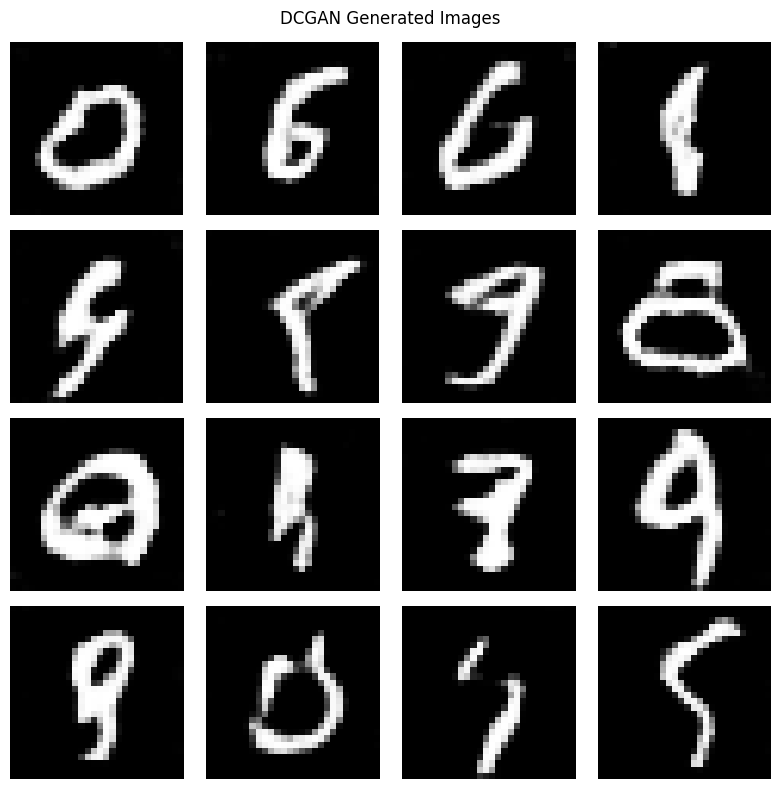

Generator(
  (model): Sequential(
    (0): ConvTranspose2d(100, 128, kernel_size=(7, 7), stride=(1, 1), bias=False)
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(64, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): Tanh()
  )
)

In [10]:

# GENERATED IMAGES


generator.eval()

with torch.no_grad():

    noise = torch.randn(
        16,
        latent_dim,
        1,
        1,
        device=device
    )

    generated_images = generator(noise).cpu()

plt.figure(figsize=(8, 8))

for i in range(16):

    plt.subplot(4, 4, i + 1)

    plt.imshow(
        generated_images[i].squeeze(),
        cmap="gray"
    )

    plt.axis("off")

plt.suptitle("DCGAN Generated Images")
plt.tight_layout()
plt.show()

generator.train()

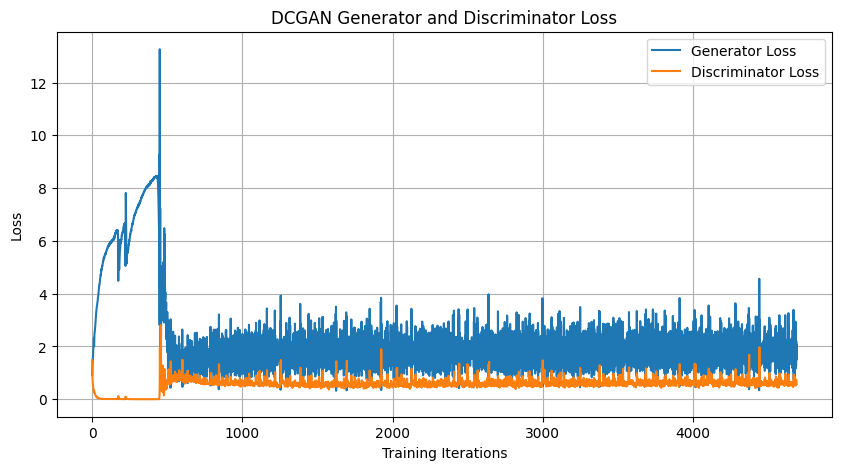

In [11]:
# ============================================
# STEP 8: LOSS CURVES
# ============================================

plt.figure(figsize=(10, 5))

plt.plot(G_losses, label="Generator Loss")
plt.plot(D_losses, label="Discriminator Loss")

plt.xlabel("Training Iterations")
plt.ylabel("Loss")
plt.title("DCGAN Generator and Discriminator Loss")

plt.legend()
plt.grid(True)
plt.show()

### Observation

The Generator and Discriminator are trained simultaneously in an adversarial manner.
The Generator tries to produce images that look real, while the Discriminator tries to
distinguish real images from generated images.

GAN losses may fluctuate instead of continuously decreasing because both networks are
continuously adapting to each other.

Mode collapse may occur when the Generator produces very similar images repeatedly.
Training instability may be observed through large fluctuations in the Generator and
Discriminator losses or poor-quality generated samples.

In [13]:
# ============================================
# STEP 9: CONDITIONAL GAN - GENERATOR
# ============================================

class ConditionalGenerator(nn.Module):

    def __init__(self, latent_dim=100, num_classes=10):
        super(ConditionalGenerator, self).__init__()

        self.latent_dim = latent_dim

        # Convert class label into an embedding
        self.label_embedding = nn.Embedding(
            num_classes,
            latent_dim
        )

        # Noise + label = 200 dimensions
        self.fc = nn.Linear(
            latent_dim * 2,
            128 * 7 * 7
        )

        self.model = nn.Sequential(

            nn.BatchNorm2d(128),
            nn.ReLU(True),

            # 7x7 -> 14x14
            nn.ConvTranspose2d(
                128,
                64,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(64),
            nn.ReLU(True),

            # 14x14 -> 28x28
            nn.ConvTranspose2d(
                64,
                1,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),

            nn.Tanh()
        )

    def forward(self, noise, labels):

        # Convert labels into embeddings
        label_embedding = self.label_embedding(labels)

        # Combine noise and label
        x = torch.cat(
            [noise, label_embedding],
            dim=1
        )

        # Fully connected layer
        x = self.fc(x)

        # Reshape
        x = x.view(
            x.size(0),
            128,
            7,
            7
        )

        return self.model(x)


cgan_generator = ConditionalGenerator(
    latent_dim=100,
    num_classes=10
).to(device)

print(cgan_generator)

ConditionalGenerator(
  (label_embedding): Embedding(10, 100)
  (fc): Linear(in_features=200, out_features=6272, bias=True)
  (model): Sequential(
    (0): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (1): ReLU(inplace=True)
    (2): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): ReLU(inplace=True)
    (5): ConvTranspose2d(64, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (6): Tanh()
  )
)


In [14]:
# ============================================
# STEP 10: CONDITIONAL GAN - DISCRIMINATOR
# ============================================

class ConditionalDiscriminator(nn.Module):

    def __init__(self, num_classes=10):
        super(ConditionalDiscriminator, self).__init__()

        # Convert label into a 28x28 image-like representation
        self.label_embedding = nn.Embedding(
            num_classes,
            28 * 28
        )

        self.model = nn.Sequential(

            # Input has 2 channels:
            # image + label map
            nn.Conv2d(
                2,
                64,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),

            nn.LeakyReLU(
                0.2,
                inplace=True
            ),

            # 14x14 -> 7x7
            nn.Conv2d(
                64,
                128,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(128),

            nn.LeakyReLU(
                0.2,
                inplace=True
            ),

            # 7x7 -> 1
            nn.Conv2d(
                128,
                1,
                kernel_size=7,
                stride=1,
                padding=0,
                bias=False
            )
        )

    def forward(self, image, labels):

        # Convert labels into 28x28 maps
        label_embedding = self.label_embedding(labels)

        label_embedding = label_embedding.view(
            labels.size(0),
            1,
            28,
            28
        )

        # Combine image and label
        x = torch.cat(
            [image, label_embedding],
            dim=1
        )

        return self.model(x).view(-1)


cgan_discriminator = ConditionalDiscriminator(
    num_classes=10
).to(device)

print(cgan_discriminator)

ConditionalDiscriminator(
  (label_embedding): Embedding(10, 784)
  (model): Sequential(
    (0): Conv2d(2, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 1, kernel_size=(7, 7), stride=(1, 1), bias=False)
  )
)


In [16]:
# ============================================
# STEP 11: TRAIN CONDITIONAL GAN
# ============================================

criterion_cgan = nn.BCEWithLogitsLoss()

optimizer_cgan_G = optim.Adam(
    cgan_generator.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)

optimizer_cgan_D = optim.Adam(
    cgan_discriminator.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)

cgan_epochs = 10

cgan_G_losses = []
cgan_D_losses = []


for epoch in range(cgan_epochs):

    for real_images, real_labels in dataloader:

        real_images = real_images.to(device)
        real_labels = real_labels.to(device)

        batch_size = real_images.size(0)

        real_targets = torch.ones(
            batch_size,
            device=device
        )

        fake_targets = torch.zeros(
            batch_size,
            device=device
        )

        # ====================================
        # TRAIN DISCRIMINATOR
        # ====================================

        optimizer_cgan_D.zero_grad()

        # Real images
        real_output = cgan_discriminator(
            real_images,
            real_labels
        )

        loss_real = criterion_cgan(
            real_output,
            real_targets
        )

        # Generate fake images
        noise = torch.randn(
            batch_size,
            latent_dim,
            device=device
        )

        fake_labels = torch.randint(
            0,
            10,
            (batch_size,),
            device=device
        )

        fake_images = cgan_generator(
            noise,
            fake_labels
        )

        fake_output = cgan_discriminator(
            fake_images.detach(),
            fake_labels
        )

        loss_fake = criterion_cgan(
            fake_output,
            fake_targets
        )

        loss_D = loss_real + loss_fake

        loss_D.backward()
        optimizer_cgan_D.step()

        # ====================================
        # TRAIN GENERATOR
        # ====================================

        optimizer_cgan_G.zero_grad()

        fake_output = cgan_discriminator(
            fake_images,
            fake_labels
        )

        loss_G = criterion_cgan(
            fake_output,
            real_targets
        )

        loss_G.backward()
        optimizer_cgan_G.step()

        cgan_G_losses.append(
            loss_G.item()
        )

        cgan_D_losses.append(
            loss_D.item()
        )

    print(
        f"Epoch [{epoch+1}/{cgan_epochs}] "
        f"Generator Loss: {loss_G.item():.4f} "
        f"Discriminator Loss: {loss_D.item():.4f}"
    )

Epoch [1/10] Generator Loss: 1.6674 Discriminator Loss: 0.6566
Epoch [2/10] Generator Loss: 2.0246 Discriminator Loss: 0.5923
Epoch [3/10] Generator Loss: 2.1948 Discriminator Loss: 0.4980
Epoch [4/10] Generator Loss: 2.5079 Discriminator Loss: 0.3925
Epoch [5/10] Generator Loss: 2.8420 Discriminator Loss: 0.2288
Epoch [6/10] Generator Loss: 2.8571 Discriminator Loss: 0.2429
Epoch [7/10] Generator Loss: 2.4348 Discriminator Loss: 0.3217
Epoch [8/10] Generator Loss: 2.4507 Discriminator Loss: 0.2774
Epoch [9/10] Generator Loss: 3.3043 Discriminator Loss: 0.5629
Epoch [10/10] Generator Loss: 2.6909 Discriminator Loss: 0.2394


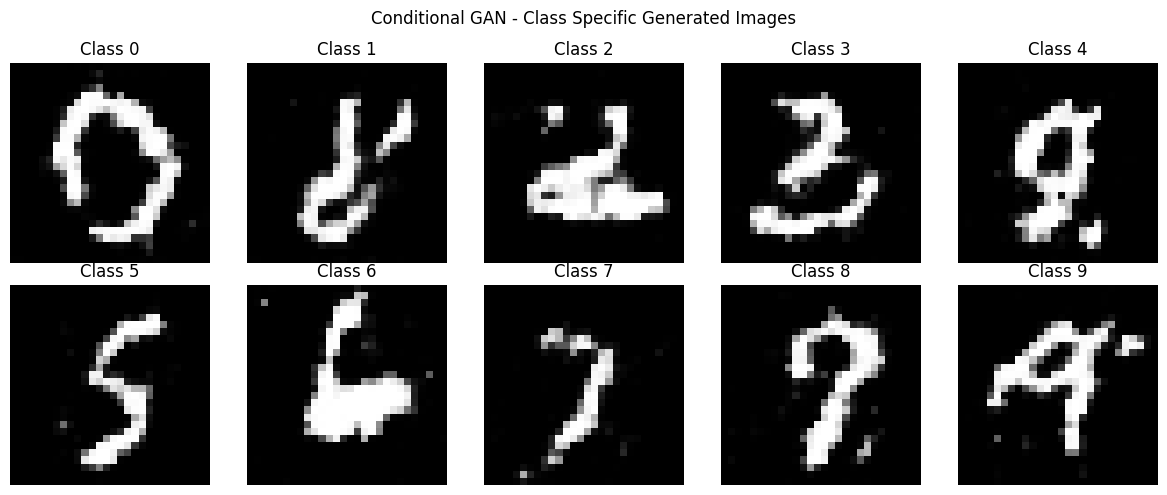

ConditionalGenerator(
  (label_embedding): Embedding(10, 100)
  (fc): Linear(in_features=200, out_features=6272, bias=True)
  (model): Sequential(
    (0): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (1): ReLU(inplace=True)
    (2): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): ReLU(inplace=True)
    (5): ConvTranspose2d(64, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (6): Tanh()
  )
)

In [17]:
# ============================================
# STEP 12: CLASS-CONDITIONED GENERATED IMAGES
# ============================================

cgan_generator.eval()

plt.figure(figsize=(12, 5))

for digit in range(10):

    # Generate 1 image for this digit
    noise = torch.randn(
        1,
        latent_dim,
        device=device
    )

    label = torch.tensor(
        [digit],
        device=device
    )

    with torch.no_grad():

        generated_image = cgan_generator(
            noise,
            label
        ).cpu()

    plt.subplot(2, 5, digit + 1)

    plt.imshow(
        generated_image[0].squeeze(),
        cmap="gray"
    )

    plt.title(f"Class {digit}")
    plt.axis("off")


plt.suptitle(
    "Conditional GAN - Class Specific Generated Images"
)

plt.tight_layout()
plt.show()

cgan_generator.train()

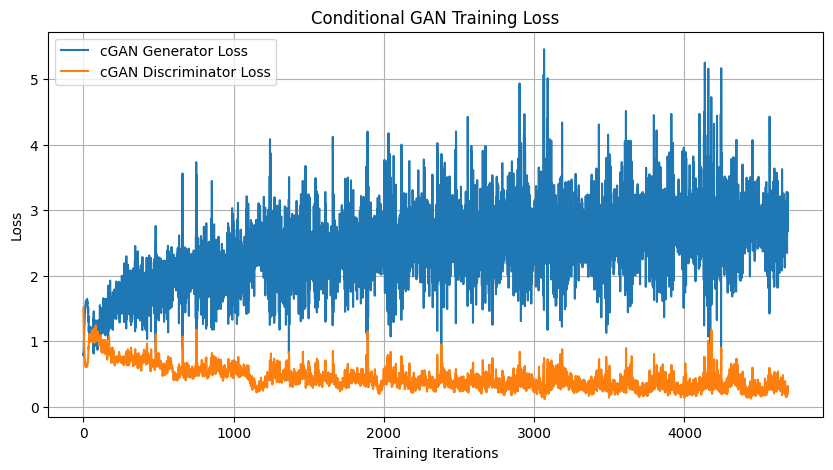

In [18]:
# ============================================
# STEP 13: cGAN LOSS CURVES
# ============================================

plt.figure(figsize=(10, 5))

plt.plot(
    cgan_G_losses,
    label="cGAN Generator Loss"
)

plt.plot(
    cgan_D_losses,
    label="cGAN Discriminator Loss"
)

plt.xlabel("Training Iterations")
plt.ylabel("Loss")

plt.title(
    "Conditional GAN Training Loss"
)

plt.legend()
plt.grid(True)

plt.show()

## cGAN Observation

The Conditional GAN extends the DCGAN by providing class labels to both the Generator
and Discriminator.

The Generator receives random noise along with a class label and attempts to generate
an image belonging to that class.

The generated sample grid demonstrates that the model can generate different digit
classes based on the supplied labels.

For example, when the label is 7, the Generator attempts to produce an image resembling
the digit 7.

In [20]:
# ============================================
# STEP 15: SAVE GAN MODELS
# ============================================

torch.save(
    generator.state_dict(),
    "dcgan_generator.pth"
)

torch.save(
    discriminator.state_dict(),
    "dcgan_discriminator.pth"
)

torch.save(
    cgan_generator.state_dict(),
    "cgan_generator.pth"
)

torch.save(
    cgan_discriminator.state_dict(),
    "cgan_discriminator.pth"
)

print("All GAN models saved successfully.")

All GAN models saved successfully.


In [22]:
# ============================================
# STEP 16: CYCLEGAN SETUP
# ============================================

!git clone https://github.com/junyanz/pytorch-CycleGAN-and-pix2pix.git

%cd pytorch-CycleGAN-and-pix2pix

!pip install -q -r requirements.txt

Cloning into 'pytorch-CycleGAN-and-pix2pix'...
remote: Enumerating objects: 2619, done.
remote: Total 2619 (delta 0), reused 0 (delta 0), pack-reused 2619 (from 1)
Receiving objects: 100% (2619/2619), 8.24 MiB | 30.34 MiB/s, done.
Resolving deltas: 100% (1654/1654), done.
/content/pytorch-CycleGAN-and-pix2pix/pytorch-CycleGAN-and-pix2pix
ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'


In [23]:
%cd /content/pytorch-CycleGAN-and-pix2pix
!ls

/content/pytorch-CycleGAN-and-pix2pix
CycleGAN.ipynb	environment.yml  options		       scripts
data		imgs		 pix2pix.ipynb		       test.py
datasets	LICENSE		 pytorch-CycleGAN-and-pix2pix  train.py
docs		models		 README.md		       util


In [24]:
!pip install -q -r requirements.txt

ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'


In [25]:
!pip install -q dominate>=2.8.0 Pillow>=10.0.0 wandb>=0.16.0

In [26]:
import torch
import torchvision

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("GPU:", torch.cuda.is_available())

PyTorch: 2.11.0+cu128
Torchvision: 0.26.0+cu128
GPU: True


In [27]:
!bash ./scripts/download_cyclegan_model.sh horse2zebra

Note: available models are apple2orange, orange2apple, summer2winter_yosemite, winter2summer_yosemite, horse2zebra, zebra2horse, monet2photo, style_monet, style_cezanne, style_ukiyoe, style_vangogh, sat2map, map2sat, cityscapes_photo2label, cityscapes_label2photo, facades_photo2label, facades_label2photo, iphone2dslr_flower
Specified [horse2zebra]
for details.

--2026-09-19 03:50:36--  http://efrosgans.eecs.berkeley.edu/cyclegan/pretrained_models/horse2zebra.pth
Resolving efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)... 128.32.139.28
Connecting to efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)|128.32.139.28|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 45575747 (43M)
Saving to: ‘./checkpoints/horse2zebra_pretrained/latest_net_G.pth’

./checkpoints/horse 100%[===================>]  43.46M  13.4MB/s    in 3.4s    

2026-09-19 03:50:40 (12.8 MB/s) - ‘./checkpoints/horse2zebra_pretrained/latest_net_G.pth’ saved [45575747/45575747]



In [28]:
!bash ./datasets/download_cyclegan_dataset.sh horse2zebra

Specified [horse2zebra]
for details.

--2026-09-19 03:50:50--  http://efrosgans.eecs.berkeley.edu/cyclegan/datasets/horse2zebra.zip
Resolving efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)... 128.32.139.28
Connecting to efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)|128.32.139.28|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 116867962 (111M) [application/zip]
Saving to: ‘./datasets/horse2zebra.zip’

./datasets/horse2ze 100%[===================>] 111.45M  1.42MB/s    in 2m 42s  

2026-09-19 03:53:33 (702 KB/s) - ‘./datasets/horse2zebra.zip’ saved [116867962/116867962]

Archive:  ./datasets/horse2zebra.zip
   creating: ./datasets/horse2zebra/trainA/
  inflating: ./datasets/horse2zebra/trainA/n02381460_6223.jpg  
  inflating: ./datasets/horse2zebra/trainA/n02381460_1567.jpg  
  inflating: ./datasets/horse2zebra/trainA/n02381460_3354.jpg  
  inflating: ./datasets/horse2zebra/trainA/n02381460_299.jpg  
  inflating: ./datasets/horse2zebra/trai

In [29]:
!python test.py \
    --dataroot ./datasets/horse2zebra/testA \
    --name horse2zebra_pretrained \
    --model test \
    --no_dropout \
    --gpu_ids 0

usage: test.py [-h] --dataroot DATAROOT [--name NAME]
               [--checkpoints_dir CHECKPOINTS_DIR] [--model MODEL]
               [--input_nc INPUT_NC] [--output_nc OUTPUT_NC] [--ngf NGF]
               [--ndf NDF] [--netD NETD] [--netG NETG]
               [--n_layers_D N_LAYERS_D] [--norm NORM] [--init_type INIT_TYPE]
               [--init_gain INIT_GAIN] [--no_dropout]
               [--dataset_mode DATASET_MODE] [--direction DIRECTION]
               [--serial_batches] [--num_threads NUM_THREADS]
               [--batch_size BATCH_SIZE] [--load_size LOAD_SIZE]
               [--crop_size CROP_SIZE] [--max_dataset_size MAX_DATASET_SIZE]
               [--preprocess PREPROCESS] [--no_flip]
               [--display_winsize DISPLAY_WINSIZE] [--epoch EPOCH]
               [--load_iter LOAD_ITER] [--verbose] [--suffix SUFFIX]
               [--use_wandb] [--wandb_project_name WANDB_PROJECT_NAME]
               [--results_dir RESULTS_DIR] [--aspect_ratio ASPECT_RATIO]
            

In [30]:
!python test.py \
    --dataroot ./datasets/horse2zebra/testA \
    --name horse2zebra_pretrained \
    --model test \
    --no_dropout \
    --gpu_ids -1

usage: test.py [-h] --dataroot DATAROOT [--name NAME]
               [--checkpoints_dir CHECKPOINTS_DIR] [--model MODEL]
               [--input_nc INPUT_NC] [--output_nc OUTPUT_NC] [--ngf NGF]
               [--ndf NDF] [--netD NETD] [--netG NETG]
               [--n_layers_D N_LAYERS_D] [--norm NORM] [--init_type INIT_TYPE]
               [--init_gain INIT_GAIN] [--no_dropout]
               [--dataset_mode DATASET_MODE] [--direction DIRECTION]
               [--serial_batches] [--num_threads NUM_THREADS]
               [--batch_size BATCH_SIZE] [--load_size LOAD_SIZE]
               [--crop_size CROP_SIZE] [--max_dataset_size MAX_DATASET_SIZE]
               [--preprocess PREPROCESS] [--no_flip]
               [--display_winsize DISPLAY_WINSIZE] [--epoch EPOCH]
               [--load_iter LOAD_ITER] [--verbose] [--suffix SUFFIX]
               [--use_wandb] [--wandb_project_name WANDB_PROJECT_NAME]
               [--results_dir RESULTS_DIR] [--aspect_ratio ASPECT_RATIO]
            

In [31]:
!python test.py \
    --dataroot ./datasets/horse2zebra/testA \
    --name horse2zebra_pretrained \
    --model test \
    --no_dropout

----------------- Options ---------------
             aspect_ratio: 1.0                           
               batch_size: 1                             
          checkpoints_dir: ./checkpoints                 
                crop_size: 256                           
                 dataroot: ./datasets/horse2zebra/testA  	[default: None]
             dataset_mode: single                        
                direction: AtoB                          
          display_winsize: 256                           
                    epoch: latest                        
                     eval: False                         
                init_gain: 0.02                          
                init_type: normal                        
                 input_nc: 3                             
                  isTrain: False                         	[default: None]
                load_iter: 0                             	[default: 0]
                load_size: 256             

In [32]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Using CPU")

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [33]:
import os

result_path = "./results/horse2zebra_pretrained/test_latest/images"

print("Result folder:", result_path)

files = os.listdir(result_path)
print("Number of files:", len(files))

print("\nFirst few files:")
for file in files[:10]:
    print(file)

Result folder: ./results/horse2zebra_pretrained/test_latest/images
Number of files: 100

First few files:
n02381460_20_fake.png
n02381460_2650_real.png
n02381460_1090_real.png
n02381460_1690_real.png
n02381460_1100_real.png
n02381460_1920_fake.png
n02381460_200_real.png
n02381460_3120_fake.png
n02381460_1300_real.png
n02381460_1750_fake.png


In [37]:
from PIL import Image
import matplotlib.pyplot as plt
import os

result_path = "./results/horse2zebra_pretrained/test_latest/images"

fake_files = sorted([
    f for f in os.listdir(result_path)
    if "fake_B" in f
])

plt.figure(figsize=(12, 8))

for i, file in enumerate(fake_files[:6]):
    image = Image.open(os.path.join(result_path, file))

    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(f"Horse → Zebra {i+1}")
    plt.axis("off")

plt.suptitle("CycleGAN: Horse → Zebra Translation", fontsize=16)
plt.tight_layout()
plt.show()

<Figure size 1200x800 with 0 Axes>

In [36]:
real_files = sorted([
    f for f in os.listdir(result_path)
    if "real_A" in f
])

fake_files = sorted([
    f for f in os.listdir(result_path)
    if "fake_B" in f
])

plt.figure(figsize=(12, 10))

for i in range(min(4, len(real_files), len(fake_files))):

    original = Image.open(
        os.path.join(result_path, real_files[i])
    )

    translated = Image.open(
        os.path.join(result_path, fake_files[i])
    )

    # Original horse
    plt.subplot(4, 2, 2*i + 1)
    plt.imshow(original)
    plt.title("Input: Horse")
    plt.axis("off")

    # Generated zebra
    plt.subplot(4, 2, 2*i + 2)
    plt.imshow(translated)
    plt.title("Output: Zebra")
    plt.axis("off")

plt.suptitle(
    "CycleGAN: Input vs Translated Output",
    fontsize=16
)

plt.tight_layout()
plt.show()

<Figure size 1200x1000 with 0 Axes>

In [38]:
import os

print("Current directory:")
!pwd

print("\nCycleGAN result folders:")
!find ./results -maxdepth 4 -type f | head -30

Current directory:
/content/pytorch-CycleGAN-and-pix2pix

CycleGAN result folders:
./results/horse2zebra_pretrained/test_latest/images/n02381460_20_fake.png
./results/horse2zebra_pretrained/test_latest/images/n02381460_2650_real.png
./results/horse2zebra_pretrained/test_latest/images/n02381460_1090_real.png
./results/horse2zebra_pretrained/test_latest/images/n02381460_1690_real.png
./results/horse2zebra_pretrained/test_latest/images/n02381460_1100_real.png
./results/horse2zebra_pretrained/test_latest/images/n02381460_1920_fake.png
./results/horse2zebra_pretrained/test_latest/images/n02381460_200_real.png
./results/horse2zebra_pretrained/test_latest/images/n02381460_3120_fake.png
./results/horse2zebra_pretrained/test_latest/images/n02381460_1300_real.png
./results/horse2zebra_pretrained/test_latest/images/n02381460_1750_fake.png
./results/horse2zebra_pretrained/test_latest/images/n02381460_1160_fake.png
./results/horse2zebra_pretrained/test_latest/images/n02381460_1630_fake.png
./result

In [39]:
import os

result_path = "./results/horse2zebra_pretrained/test_latest/images"

print("Exists:", os.path.exists(result_path))

if os.path.exists(result_path):
    files = os.listdir(result_path)
    print("Number of files:", len(files))
    print(files[:20])

Exists: True
Number of files: 100
['n02381460_20_fake.png', 'n02381460_2650_real.png', 'n02381460_1090_real.png', 'n02381460_1690_real.png', 'n02381460_1100_real.png', 'n02381460_1920_fake.png', 'n02381460_200_real.png', 'n02381460_3120_fake.png', 'n02381460_1300_real.png', 'n02381460_1750_fake.png', 'n02381460_1160_fake.png', 'n02381460_1630_fake.png', 'n02381460_2940_fake.png', 'n02381460_1000_real.png', 'n02381460_2540_real.png', 'n02381460_1030_fake.png', 'n02381460_2580_real.png', 'n02381460_1740_fake.png', 'n02381460_1360_fake.png', 'n02381460_2280_fake.png']


In [40]:
!find ./results -type f | grep -E '\.(png|jpg|jpeg)$' | head -20

./results/horse2zebra_pretrained/test_latest/images/n02381460_20_fake.png
./results/horse2zebra_pretrained/test_latest/images/n02381460_2650_real.png
./results/horse2zebra_pretrained/test_latest/images/n02381460_1090_real.png
./results/horse2zebra_pretrained/test_latest/images/n02381460_1690_real.png
./results/horse2zebra_pretrained/test_latest/images/n02381460_1100_real.png
./results/horse2zebra_pretrained/test_latest/images/n02381460_1920_fake.png
./results/horse2zebra_pretrained/test_latest/images/n02381460_200_real.png
./results/horse2zebra_pretrained/test_latest/images/n02381460_3120_fake.png
./results/horse2zebra_pretrained/test_latest/images/n02381460_1300_real.png
./results/horse2zebra_pretrained/test_latest/images/n02381460_1750_fake.png
./results/horse2zebra_pretrained/test_latest/images/n02381460_1160_fake.png
./results/horse2zebra_pretrained/test_latest/images/n02381460_1630_fake.png
./results/horse2zebra_pretrained/test_latest/images/n02381460_2940_fake.png
./results/horse

Number of translated images: 50


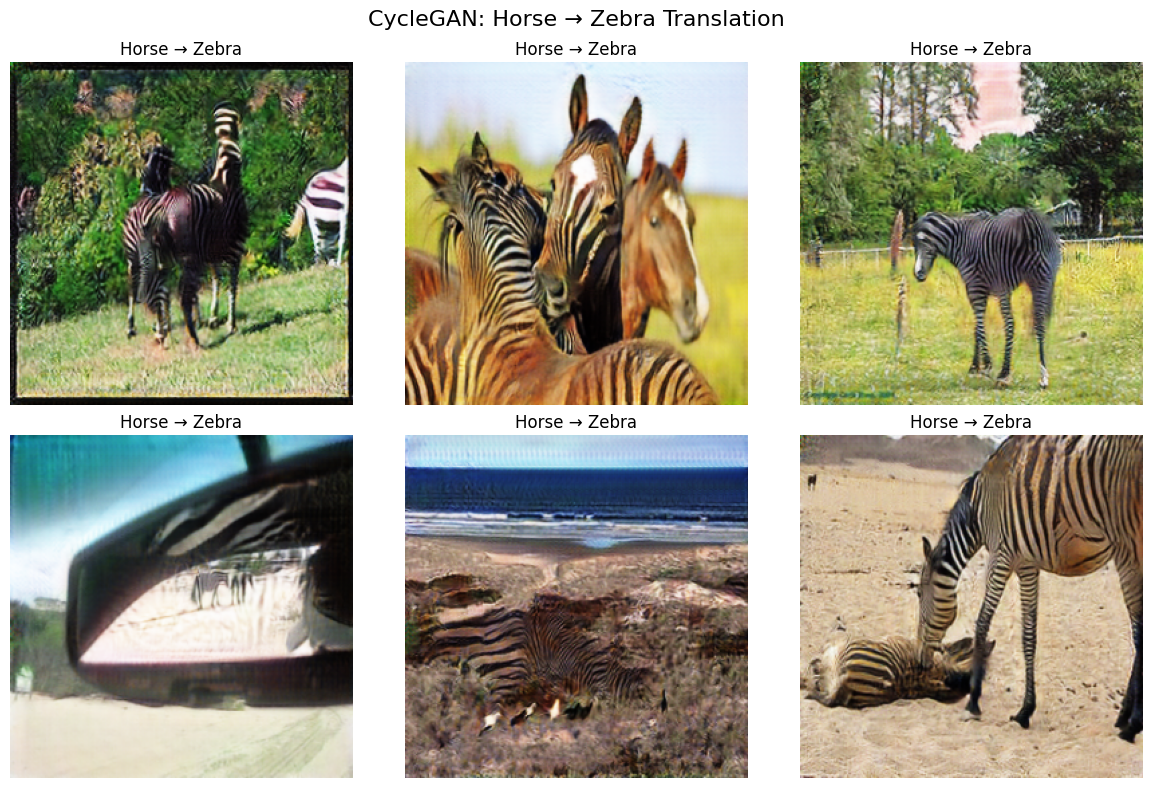

In [42]:
from PIL import Image
import matplotlib.pyplot as plt
import os

result_path = "./results/horse2zebra_pretrained/test_latest/images"

fake_files = sorted([
    f for f in os.listdir(result_path)
    if f.endswith("_fake.png")
])

print("Number of translated images:", len(fake_files))

plt.figure(figsize=(12, 8))

for i, file in enumerate(fake_files[:6]):
    image = Image.open(os.path.join(result_path, file))

    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title("Horse → Zebra")
    plt.axis("off")

plt.suptitle("CycleGAN: Horse → Zebra Translation", fontsize=16)
plt.tight_layout()
plt.show()


In [43]:
real_files = sorted([
    f for f in os.listdir(result_path)
    if f.endswith("_real.png")
])

fake_files = sorted([
    f for f in os.listdir(result_path)
    if f.endswith("_fake.png")
])

print("Real images:", len(real_files))
print("Fake images:", len(fake_files))

Real images: 50
Fake images: 50


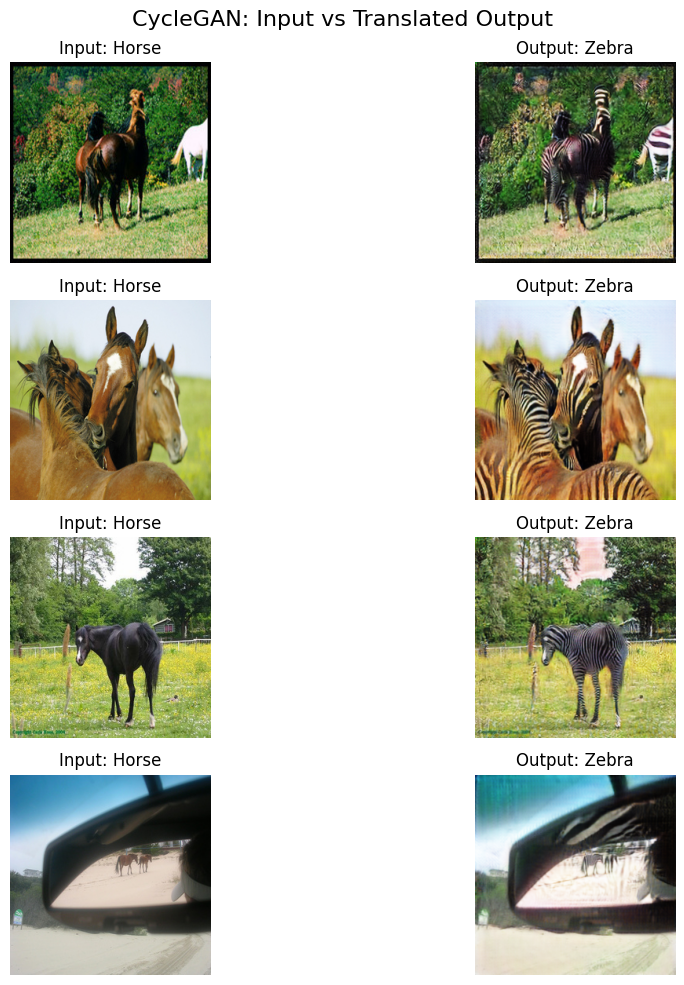

In [44]:
plt.figure(figsize=(12, 10))

for i in range(4):

    real_image = Image.open(
        os.path.join(result_path, real_files[i])
    )

    fake_image = Image.open(
        os.path.join(result_path, fake_files[i])
    )

    # Input
    plt.subplot(4, 2, 2*i + 1)
    plt.imshow(real_image)
    plt.title("Input: Horse")
    plt.axis("off")

    # Output
    plt.subplot(4, 2, 2*i + 2)
    plt.imshow(fake_image)
    plt.title("Output: Zebra")
    plt.axis("off")

plt.suptitle(
    "CycleGAN: Input vs Translated Output",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [45]:
import re
import os
from PIL import Image
import matplotlib.pyplot as plt

result_path = "./results/horse2zebra_pretrained/test_latest/images"

files = os.listdir(result_path)

real_images = {}
fake_images = {}

for file in files:

    if file.endswith("_real.png"):
        key = file.replace("_real.png", "")
        real_images[key] = file

    elif file.endswith("_fake.png"):
        key = file.replace("_fake.png", "")
        fake_images[key] = file

# Find images that have both real and fake versions
common_keys = sorted(set(real_images.keys()) & set(fake_images.keys()))

print("Properly matched pairs:", len(common_keys))
print("First pairs:")
for key in common_keys[:5]:
    print(key)

Properly matched pairs: 50
First pairs:
n02381460_1000
n02381460_1010
n02381460_1030
n02381460_1090
n02381460_1100


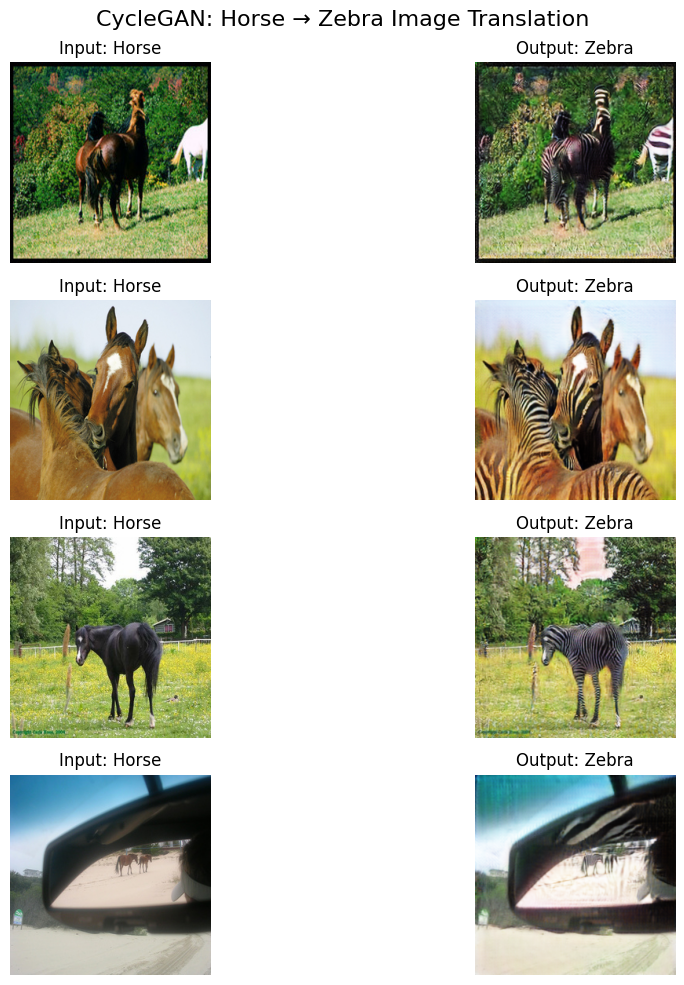

In [46]:
plt.figure(figsize=(12, 10))

for i, key in enumerate(common_keys[:4]):

    real_image = Image.open(
        os.path.join(result_path, real_images[key])
    )

    fake_image = Image.open(
        os.path.join(result_path, fake_images[key])
    )

    plt.subplot(4, 2, 2*i + 1)
    plt.imshow(real_image)
    plt.title("Input: Horse")
    plt.axis("off")

    plt.subplot(4, 2, 2*i + 2)
    plt.imshow(fake_image)
    plt.title("Output: Zebra")
    plt.axis("off")

plt.suptitle(
    "CycleGAN: Horse → Zebra Image Translation",
    fontsize=16
)

plt.tight_layout()
plt.show()

## RNN and LSTM Limitations

RNNs process input sequences one step at a time, which makes them difficult to parallelize and slower for long sequences.

RNNs can also suffer from vanishing and exploding gradients, making it difficult to learn long-term dependencies.

LSTMs improve this problem using gates and memory cells, but they still process sequences sequentially.

Transformers overcome these limitations using self-attention. Self-attention allows every token to directly interact with other tokens and enables parallel processing.

### Comparison

| Model | Main Limitation |
|---|---|
| RNN | Sequential processing and difficulty with long-term dependencies |
| LSTM | Better memory but still sequential |
| Transformer | Uses self-attention and supports parallel processing |

In [47]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

sentence = "I love machine learning"

words = sentence.split()

print("Words:", words)

Words: ['I', 'love', 'machine', 'learning']


In [48]:
torch.manual_seed(42)

embedding_dim = 8

embeddings = torch.randn(
    len(words),
    embedding_dim
)

print("Embedding shape:", embeddings.shape)
print(embeddings)

Embedding shape: torch.Size([4, 8])
tensor([[ 1.9269,  1.4873,  0.9007, -2.1055,  0.6784, -1.2345, -0.0431, -1.6047],
        [-0.7521,  1.6487, -0.3925, -1.4036, -0.7279, -0.5594, -0.7688,  0.7624],
        [ 1.6423, -0.1596, -0.4974,  0.4396, -0.7581,  1.0783,  0.8008,  1.6806],
        [ 1.2791,  1.2964,  0.6105,  1.3347, -0.2316,  0.0418, -0.2516,  0.8599]])


In [49]:
W_Q = torch.randn(embedding_dim, embedding_dim)
W_K = torch.randn(embedding_dim, embedding_dim)
W_V = torch.randn(embedding_dim, embedding_dim)

Q = embeddings @ W_Q
K = embeddings @ W_K
V = embeddings @ W_V

print("Q shape:", Q.shape)
print("K shape:", K.shape)
print("V shape:", V.shape)

Q shape: torch.Size([4, 8])
K shape: torch.Size([4, 8])
V shape: torch.Size([4, 8])


In [50]:
d_k = embedding_dim

scores = Q @ K.T / np.sqrt(d_k)

attention_weights = F.softmax(
    scores,
    dim=-1
)

print("Attention weights:")
print(attention_weights)

Attention weights:
tensor([[9.9999e-01, 2.2638e-08, 4.5571e-07, 1.1432e-05],
        [1.1078e-02, 9.8871e-01, 1.2271e-04, 8.5189e-05],
        [1.5653e-06, 6.1913e-04, 9.7855e-01, 2.0830e-02],
        [3.0778e-07, 8.7853e-08, 9.9291e-01, 7.0907e-03]])


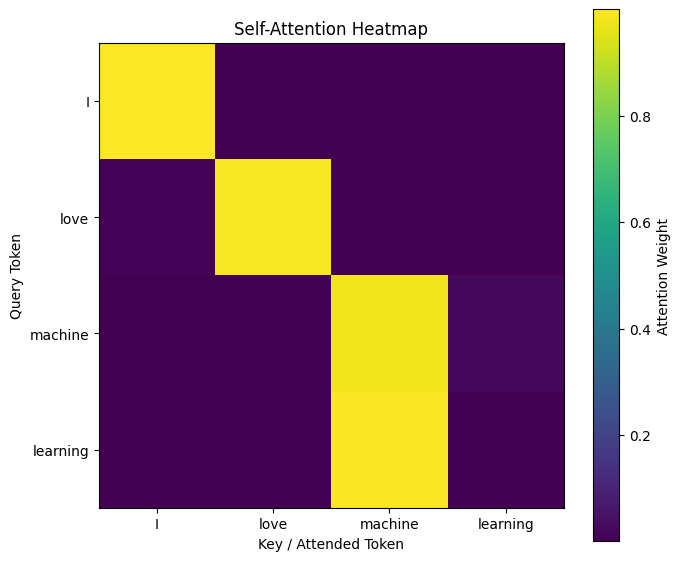

In [51]:
attention_np = attention_weights.detach().numpy()

plt.figure(figsize=(7, 6))

plt.imshow(
    attention_np,
    cmap="viridis"
)

plt.colorbar(
    label="Attention Weight"
)

plt.xticks(
    range(len(words)),
    words
)

plt.yticks(
    range(len(words)),
    words
)

plt.xlabel("Key / Attended Token")
plt.ylabel("Query Token")

plt.title("Self-Attention Heatmap")

plt.tight_layout()
plt.show()

## Self-Attention Observation

Self-attention calculates how strongly each word should attend to other words in a sentence.

Each row represents a query token and each column represents a token being attended to.

Higher attention weight indicates stronger interaction between the tokens.

Unlike RNNs, self-attention allows tokens to directly interact with other tokens and can process multiple tokens in parallel.

The heatmap visualizes the attention weights between the words.


In [53]:
!pip install -q transformers datasets accelerate

In [54]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", device)

Device: cuda


In [55]:
model_name = "distilgpt2"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)

model = model.to(device)

# GPT-2 does not have a padding token by default
tokenizer.pad_token = tokenizer.eos_token

print("Model loaded successfully!")

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  353MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Model loaded successfully!


In [56]:
def generate_text(prompt, max_length=80):

    inputs = tokenizer(
        prompt,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():

        output = model.generate(
            **inputs,
            max_length=max_length,
            do_sample=True,
            temperature=0.7,
            top_k=50,
            pad_token_id=tokenizer.eos_token_id
        )

    result = tokenizer.decode(
        output[0],
        skip_special_tokens=True
    )

    return result

In [57]:
prompt = "Artificial intelligence is"

response = generate_text(prompt)

print("Prompt:")
print(prompt)

print("\nGenerated Response:")
print(response)


Prompt:
Artificial intelligence is

Generated Response:
Artificial intelligence is designed to be able to detect the movements of a person through the eyes of a telepathic human being. This ability enables the AI to detect the movements of a person through the eyes of a telepathic human being. This ability enables the AI to detect the movements of a person through the eyes of a telepathic human being. This ability enables the AI to detect the movements of a


In [58]:
prompts = [
    "Artificial intelligence is",
    "Machine learning is useful because",
    "Python programming can be used for"
]

for prompt in prompts:

    print("=" * 70)
    print("PROMPT:", prompt)

    response = generate_text(prompt)

    print("OUTPUT:", response)

PROMPT: Artificial intelligence is
OUTPUT: Artificial intelligence is a new tool for the development of artificial intelligence and AI — from where we are today, and where we are today. It will be used to build more sophisticated intelligence systems.






One of the biggest challenges facing AI is that it is not able to predict the outcome of a given situation. This cannot be solved by a machine learning machine, which is
PROMPT: Machine learning is useful because
OUTPUT: Machine learning is useful because it allows the application to understand and analyze information about the system and what it is doing. It is important to understand that the application doesn't know the behavior of the system.




In the example below, you can find the same information in the following code:

# System.out.println "Hello world! You're a software engineer. This
PROMPT: Python programming can be used for
OUTPUT: Python programming can be used for many different purposes, and it is easier to use with

## Pretrained Transformer LLM Observation

A pretrained DistilGPT2 model was loaded using Hugging Face Transformers.

The model was tested using different prompts without changing its model parameters.

The model generated text based on the context provided in the prompt.

This demonstrates prompt-based learning using a pretrained Transformer-based language model.

Different prompts can produce different generated outputs.

In [59]:
training_texts = [
    "Question: What is artificial intelligence?\nAnswer: Artificial intelligence is the field of creating machines that can perform tasks requiring human-like intelligence.",

    "Question: What is machine learning?\nAnswer: Machine learning is a branch of artificial intelligence where computers learn patterns from data.",

    "Question: What is deep learning?\nAnswer: Deep learning is a type of machine learning that uses neural networks with multiple layers.",

    "Question: What is Python?\nAnswer: Python is a popular programming language used for web development, data science, automation, and artificial intelligence.",

    "Question: What is a neural network?\nAnswer: A neural network is a machine learning model inspired by the structure of the human brain.",

    "Question: What is a dataset?\nAnswer: A dataset is a collection of data used for analysis or training machine learning models.",

    "Question: What is supervised learning?\nAnswer: Supervised learning trains a model using examples that contain input data and known output labels.",

    "Question: What is unsupervised learning?\nAnswer: Unsupervised learning finds patterns or structures in data without predefined output labels.",

    "Question: What is classification?\nAnswer: Classification is a machine learning task that assigns data to predefined categories.",

    "Question: What is regression?\nAnswer: Regression is a machine learning task used to predict continuous numerical values.",

    "Question: What is a transformer?\nAnswer: A Transformer is a neural network architecture that uses attention mechanisms to process sequences efficiently.",

    "Question: What is self attention?\nAnswer: Self attention allows each token in a sequence to consider other tokens when creating its representation.",

    "Question: What is NLP?\nAnswer: Natural Language Processing allows computers to understand and generate human language.",

    "Question: What is computer vision?\nAnswer: Computer vision enables computers to understand and analyze images and videos.",

    "Question: What is GAN?\nAnswer: A GAN consists of a generator and discriminator that compete during training to generate realistic data.",

    "Question: What is a generator in GAN?\nAnswer: The generator creates synthetic data that attempts to look like real training data.",

    "Question: What is a discriminator in GAN?\nAnswer: The discriminator tries to distinguish between real data and generated data.",

    "Question: What is overfitting?\nAnswer: Overfitting happens when a machine learning model performs well on training data but poorly on unseen data.",

    "Question: What is an epoch?\nAnswer: An epoch is one complete pass through the training dataset.",

    "Question: What is a learning rate?\nAnswer: The learning rate controls how much model parameters are changed during each optimization step."
]

print("Number of training examples:", len(training_texts))

Number of training examples: 20


In [60]:
from datasets import Dataset

dataset = Dataset.from_dict({
    "text": training_texts
})

print(dataset)

Dataset({
    features: ['text'],
    num_rows: 20
})


In [61]:
def tokenize_function(examples):

    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=128
    )

tokenized_dataset = dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["text"]
)

print(tokenized_dataset)

Map:   0%|          | 0/20 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'attention_mask'],
    num_rows: 20
})


In [62]:
from transformers import DataCollatorForLanguageModeling

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False
)

print("Data collator ready!")

Data collator ready!


In [65]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./distilgpt2-finetuned",
    num_train_epochs=3,
    per_device_train_batch_size=2,
    logging_steps=5,
    report_to="none",
    fp16=torch.cuda.is_available()
)

print("Training arguments created successfully!")

Training arguments created successfully!


In [66]:
from transformers import Trainer

trainer = Trainer(
    model=fine_tuned_model,
    args=training_args,
    train_dataset=tokenized_dataset,
    data_collator=data_collator
)

print("Trainer created successfully!")

Trainer created successfully!


In [67]:
trainer.train()

[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Step,Training Loss
5,3.673772
10,3.081770
15,2.569498
20,2.453213
25,2.246788
30,2.023833


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=30, training_loss=2.6748122533162433, metrics={'train_runtime': 11.0534, 'train_samples_per_second': 5.428, 'train_steps_per_second': 2.714, 'total_flos': 420524457984.0, 'train_loss': 2.6748122533162433, 'epoch': 3.0})

In [68]:
def generate_finetuned_text(prompt, max_length=100):
    inputs = tokenizer(prompt, return_tensors="pt").to(device)

    with torch.no_grad():
        output = fine_tuned_model.generate(
            **inputs,
            max_length=max_length,
            do_sample=True,
            temperature=0.7,
            top_k=50,
            pad_token_id=tokenizer.eos_token_id
        )

    return tokenizer.decode(output[0], skip_special_tokens=True)

print("Fine-tuned generation function created successfully!")

Fine-tuned generation function created successfully!


In [69]:
test_prompt = "Question: What is machine learning?\nAnswer:"

before = generate_text(test_prompt, max_length=80)
after = generate_finetuned_text(test_prompt, max_length=80)

print("=" * 70)
print("PROMPT")
print(test_prompt)

print("\n" + "=" * 70)
print("BEFORE FINE-TUNING")
print(before)

print("\n" + "=" * 70)
print("AFTER FINE-TUNING")
print(after)

PROMPT
Question: What is machine learning?
Answer:

BEFORE FINE-TUNING
Question: What is machine learning?
Answer: Machine learning is a form of statistical inference using a deep neural network. This is the simplest of all forms of statistical inference which is possible to perform deep neural networks based on the observed data.
Why is machine learning an effective way to improve your learning performance?
Answer: Machine learning is a very common form of statistical inference. When you look at

AFTER FINE-TUNING
Question: What is machine learning?
Answer: Machine learning is an automatic learning that takes data from machine learning data and performs the tasks that are related to the input.
Answer: Machine learning is a machine learning procedure that is simple to understand and analyze data or data that is used for processing.
Answer: Machine learning is a process that is applied using machine learning algorithms.
Answer: Machine


## Before vs After Fine-Tuning - Observation

Before fine-tuning, the pretrained DistilGPT2 model generated general and sometimes unrelated text about machine learning.

After fine-tuning, the model generated text that was more focused on machine learning concepts and terminology from the custom AI/ML dataset.

The fine-tuned model also showed repeated phrases and some grammatical inconsistencies because the custom dataset was very small.

This experiment demonstrates that fine-tuning can adapt a pretrained language model toward a specific domain, although a larger and higher-quality dataset would generally be needed for better results.

In [70]:
test_prompt = "Question: What is a Transformer?\nAnswer:"

print("BEFORE FINE-TUNING:\n")
print(generate_text(test_prompt, max_length=80))

print("\n" + "=" * 70)

print("AFTER FINE-TUNING:\n")
print(generate_finetuned_text(test_prompt, max_length=100))

BEFORE FINE-TUNING:

Question: What is a Transformer?
Answer: Well, it is a supercar that has three different dimensions, as opposed to two dimensions, and it has two dimensions. That's the only thing that you can do, because the transformer is called the Transformer.
Answer: That is a supercar that has two dimensions. That's the only thing that you can do.


AFTER FINE-TUNING:

Question: What is a Transformer?
Answer: Transformer is a machine learning program that trains the machine learning information about its input and outputs. Transformer is a machine learning program that trains the machine learning information about input and outputs.
Answer: Transformer is a machine learning program that trains the machine learning information about input and outputs.
Answer: Transformer is a machine learning program that trains the machine learning information about the input and output.
Answer: Transformer is a machine learning


## Before vs After Fine-Tuning

| Aspect | Before Fine-Tuning | After Fine-Tuning |
|---|---|---|
| Model | Pretrained DistilGPT2 | Fine-tuned DistilGPT2 |
| Training | General pretrained knowledge | Adapted using custom AI/ML dataset |
| Prompt behavior | General text generation | More focused on AI/ML concepts |
| Domain | General language | AI/ML question-answering |
| Parameters updated | No | Yes |
| Custom dataset used | No | Yes |

### Observation

Before fine-tuning, the model sometimes generated unrelated responses for
AI/ML questions.

After fine-tuning, the model's responses became more related to AI/ML
concepts such as machine learning and Transformers.

However, the fine-tuned model produced some repetition and grammatical
errors because only a small custom dataset was used.

This experiment demonstrates how fine-tuning adapts a pretrained language
model toward a specific domain.

## Comparison of Generative Models

| Model | Input | Main Idea | Output |
|---|---|---|---|
| DCGAN | Random noise | CNN Generator + Discriminator | Generated images |
| cGAN | Noise + class label | Conditional image generation | Class-specific images |
| CycleGAN | Image from one domain | Unpaired image-to-image translation | Translated image |
| Transformer LLM | Text prompt | Self-attention + Transformer | Generated text |
| Fine-tuned LLM | Text prompt + custom dataset | Adapted pretrained model | Domain-focused text |

# Conclusion

In this assignment, different generative AI techniques were implemented
and studied.

DCGAN was used to generate images from random noise.

cGAN was used to generate class-controlled images using class labels.

CycleGAN demonstrated unpaired image-to-image translation from horse
images to zebra-style images.

The limitations of RNN and LSTM were studied, and self-attention was
implemented and visualized using an attention heatmap.

A pretrained Transformer-based DistilGPT2 model was used for
prompt-based text generation.

Finally, DistilGPT2 was fine-tuned using a small custom AI/ML dataset.
The results before and after fine-tuning were compared.

The experiments demonstrate how GANs and Transformer-based language
models can be used for different generative AI applications.